# TimeGAN training balance: the initial price jump

Four fresh runs compare discriminator learning rates **3e-4 (baseline), 1e-4,
and 3e-5**, plus **two generator updates per discriminator update** at the
baseline rates. Generator and embedder/decoder learning rates stay at 3e-4.
Architecture, noise amplitude 1, and stage budgets are fixed: 1,000 reconstruction,
1,000 transition, and 5,000 joint iterations.

Every run uses training seed 0 and the same independently seeded data sampler.
This is a newly trained controlled baseline; it need not reproduce the older
checkpoint, whose data sampler shared the training noise RNG.
The two-update variant takes 10,000 joint generator updates, versus 5,000 in the
other settings, with the same discriminator and embedder/decoder update counts.

The main question is whether the generated price still rises quickly when
continuation begins. Diagnostics use **eight real starting contexts, 32
completions per context, and identical noise draws across models**. Later
validation contexts include only observations preceding their own prediction.
Training uses no validation data. Zero-noise rollouts expose deterministic drift;
they are a diagnostic outside the training noise distribution.

Each result has a whole-day completion chart and a zoom into the first 128
events. Long continuations preserve training noise variance per event and extend
far beyond the training horizon. The shaded zoom region is one standard
deviation across completions, not a confidence interval.


In [1]:
from pathlib import Path
import sys
import json

project_dir = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "dataset.py").exists()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Launch from the recognition project.")
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dataset import LOBSTERLevel10Dataset

RESULTS_DIR = project_dir / "runs" / "training_balance"
EXPERIMENTS = [
    "baseline", "discriminator_1e-4", "discriminator_3e-5", "generator_twice",
]
LABELS = {
    "baseline": "Baseline: D rate 3e-4",
    "discriminator_1e-4": "D rate 1e-4",
    "discriminator_3e-5": "D rate 3e-5",
    "generator_twice": "Two G updates per D update",
}


In [2]:
results = {}
summary_rows = []
snapshot_rows = []
for name in EXPERIMENTS:
    directory = RESULTS_DIR / f"{name}_seed_0"
    metadata = json.loads((directory / "run.json").read_text())
    step = metadata["training_config"]["joint_steps"]
    diagnostic = json.loads((directory / f"diagnostics_step_{step}.json").read_text())
    with np.load(directory / "completion_midpoints.npz") as archive:
        full_curves = {key: archive[key].copy() for key in archive.files}
    history = pd.read_csv(directory / "losses.csv")
    final_losses = history.loc[history["stage"] == "joint"].tail(100)
    results[name] = {
        "metadata": metadata, "diagnostic": diagnostic, "full": full_curves,
        "contexts": pd.read_csv(directory / f"contexts_step_{step}.csv"),
    }
    summary_rows.append({
        "experiment": LABELS[name],
        **diagnostic["metrics"],
        "boundary_peak_mean_rise_64_dollars": max(0.0, max(diagnostic["curves"]["generated_mean"][:64])
                                                    - diagnostic["curves"]["starting_price_dollars"]),
        "boundary_max_mean_abs_error_64_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"][:64])
            - np.array(diagnostic["curves"]["observed"][:64])))),
        "boundary_max_mean_abs_error_128_dollars": float(np.max(np.abs(
            np.array(diagnostic["curves"]["generated_mean"])
            - np.array(diagnostic["curves"]["observed"])))),
        "discriminator_learning_rate": metadata["training_config"]["discriminator_learning_rate"],
        "generator_updates": metadata["training_config"]["generator_updates"],
        "last100_discriminator_loss": final_losses["discriminator"].mean(),
        "last100_generator_adversarial_loss": final_losses["adversarial"].mean(),
        "training_minutes": metadata["training_seconds"] / 60,
    })
    snapshots = pd.read_csv(directory / "snapshots.csv")
    snapshots["experiment"] = LABELS[name]
    snapshot_rows.extend(snapshots.to_dict("records"))

summary = pd.DataFrame(summary_rows).set_index("experiment")
snapshots = pd.DataFrame(snapshot_rows)
summary.to_csv(RESULTS_DIR / "summary.csv")
snapshots.to_csv(RESULTS_DIR / "all_snapshots.csv", index=False)
display(summary[[
    "discriminator_learning_rate", "generator_updates", "training_minutes",
]].round(6))


,discriminator_learning_rate,generator_updates,training_minutes
experiment,,,
Baseline: D rate 3e-4,0.00030,1,17.077918
D rate 1e-4,0.00010,1,17.171269
D rate 3e-5,0.00003,1,17.070761
Two G updates per D update,0.00030,2,20.373258


## Reference: the original saved model

Under the same 32-completion diagnostic, the original checkpoint rises **$3.31** on average after 64 events,
or **$3.46** with zero noise. Its average endpoint error over the eight contexts is
**$3.57**. This reference is the earlier saved model, separate from the freshly
trained controlled baseline in the tables below.


## Does the initial jump improve?

The peak rise catches an early overshoot even if the price later falls back.
The 64-event change is measured from the last observed price. Positive values
mean the continuation rises; negative values mean it falls. The actual
64-event change is shown below. Across-context error measures the absolute error
of the ensemble mean endpoint, averaged over eight starting contexts.
A smaller jump alone does not establish realistic volatility or book dynamics.


In [3]:
display(summary[[
    "boundary_first_event_change_dollars",
    "boundary_peak_mean_rise_64_dollars",
    "boundary_max_mean_abs_error_64_dollars",
    "boundary_64_event_change_dollars",
    "boundary_64_event_std_dollars",
    "boundary_zero_noise_64_event_change_dollars",
    "context_mean_abs_64_event_error_dollars",
]].rename(columns={
    "boundary_first_event_change_dollars": "First-event change ($)",
    "boundary_peak_mean_rise_64_dollars": "Peak mean rise in first 64 events ($)",
    "boundary_max_mean_abs_error_64_dollars": "Largest mean error in first 64 events ($)",
    "boundary_64_event_change_dollars": "64-event change ($)",
    "boundary_64_event_std_dollars": "Endpoint SD ($)",
    "boundary_zero_noise_64_event_change_dollars": "Zero-noise 64-event change ($)",
    "context_mean_abs_64_event_error_dollars": "Eight-context endpoint error ($)",
}).round(4))
observed_change = results["baseline"]["diagnostic"]["metrics"]["boundary_observed_64_event_change_dollars"]
print(f"Actual observed change over the first 64 validation events: {observed_change:+.4f} dollars")


Actual observed change over the first 64 validation events: +0.0000 dollars


,First-event change ($),Peak mean rise in first 64 events ($),Largest mean error in first 64 events ($),64-event change ($),Endpoint SD ($),Zero-noise 64-event change ($),Eight-context endpoint error ($)
experiment,,,,,,,
Baseline: D rate 3e-4,-0.1391,0.0000,0.4222,-0.4222,0.1955,-0.455,0.4281
D rate 1e-4,0.0672,1.2094,1.2094,1.2094,0.5624,1.065,1.5030
D rate 3e-5,0.1000,2.1161,2.1161,1.9161,0.2740,1.880,1.7868
Two G updates per D update,0.1138,2.1333,2.1333,2.1333,0.2471,2.125,1.9164


In [4]:
training = LOBSTERLevel10Dataset(train=True)
validation = LOBSTERLevel10Dataset(train=False)

def midpoint(book):
    return ((book["ASKp1"] + book["BIDp1"]) / 20_000).to_numpy()

training_price = midpoint(training.books)
validation_price = midpoint(validation.books)
boundary, horizon = len(training), len(validation)

full_arrays = [training_price, validation_price]
early_arrays = []
for result in results.values():
    full_arrays.extend([result["full"]["noisy"].ravel(), result["full"]["zero"]])
    curves = result["diagnostic"]["curves"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    early_arrays.extend([np.array(curves["observed"]), np.array(curves["zero_noise"]),
                         mean - std, mean + std, np.array([curves["starting_price_dollars"]])])

def price_limits(arrays):
    low = min(array.min() for array in arrays)
    high = max(array.max() for array in arrays)
    margin = max(0.05 * (high - low), 0.01)
    return low - margin, high + margin

full_limits, early_limits = price_limits(full_arrays), price_limits(early_arrays)


def plot_experiment(name):
    result = results[name]
    fig, axes = plt.subplots(
        1, 2, figsize=(17, 5), width_ratios=[1.7, 1], layout="constrained",
    )
    ax = axes[0]
    ax.plot(np.arange(boundary), training_price, color="tab:blue", label="Training")
    ax.plot(np.arange(boundary, boundary + horizon), validation_price,
            color="tab:orange", label="Validation")
    events = np.arange(boundary - 1, boundary + horizon)
    for index, prices in enumerate(result["full"]["noisy"]):
        ax.plot(events, np.r_[training_price[-1], prices], color="tab:green", alpha=0.5,
                label="Three completions" if index == 0 else None)
    ax.plot(events, np.r_[training_price[-1], result["full"]["zero"]],
            color="black", linestyle="--", linewidth=1, label="Zero noise")
    ax.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=1)
    ax.set(title="Whole-day midpoint and completions", xlabel="Event index",
           ylabel="Midpoint ($)", ylim=full_limits)
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.legend(fontsize=9)

    ax = axes[1]
    curves = result["diagnostic"]["curves"]
    start = curves["starting_price_dollars"]
    mean, std = np.array(curves["generated_mean"]), np.array(curves["generated_std"])
    events = np.arange(len(mean) + 1)
    ax.plot(events, np.r_[start, curves["observed"]], color="tab:orange", label="Observed")
    ax.plot(events, np.r_[start, mean], color="tab:green", label="Mean of 32 completions")
    ax.fill_between(events, np.r_[start, mean - std], np.r_[start, mean + std],
                    color="tab:green", alpha=0.15, label="One completion SD")
    ax.plot(events, np.r_[start, curves["zero_noise"]], color="black",
            linestyle="--", label="Zero noise")
    ax.axvline(64, color="gray", linestyle=":", linewidth=1)
    ax.set(title="First 128 generated events", xlabel="Events after training boundary",
           ylabel="Midpoint ($)", ylim=early_limits)
    ax.legend(fontsize=9)
    fig.suptitle(LABELS[name])
    plt.show()


## Baseline


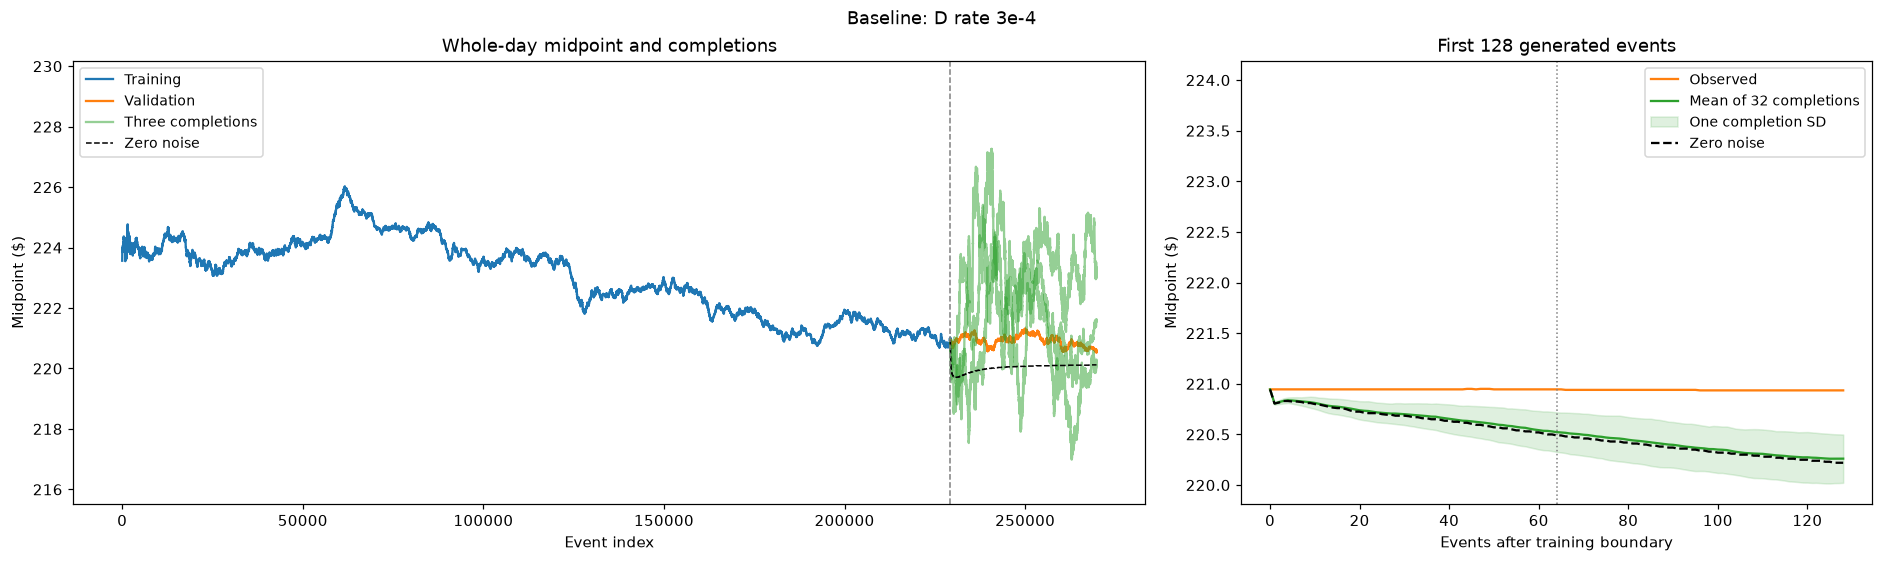

In [5]:
plot_experiment("baseline")


## Slower discriminator: 1e-4


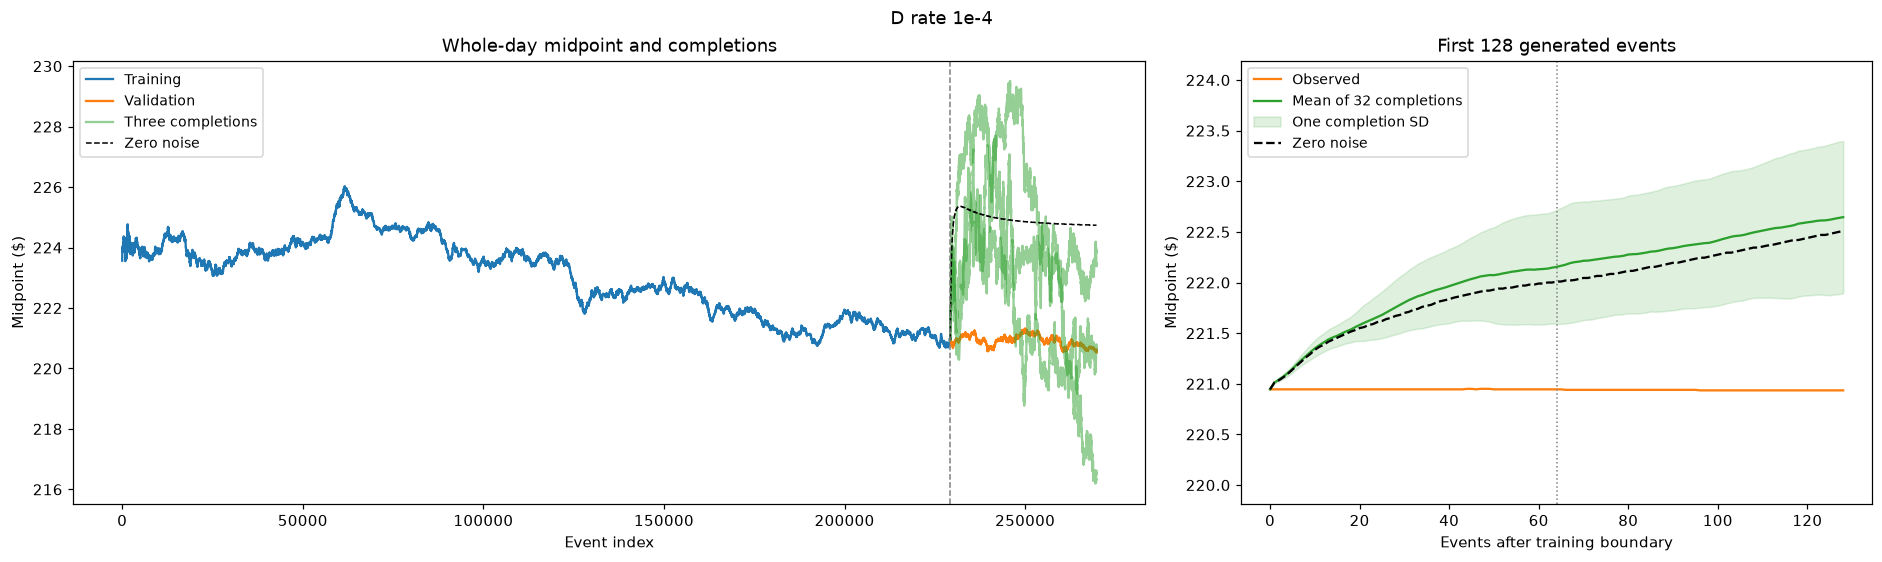

In [6]:
plot_experiment("discriminator_1e-4")


## Much slower discriminator: 3e-5


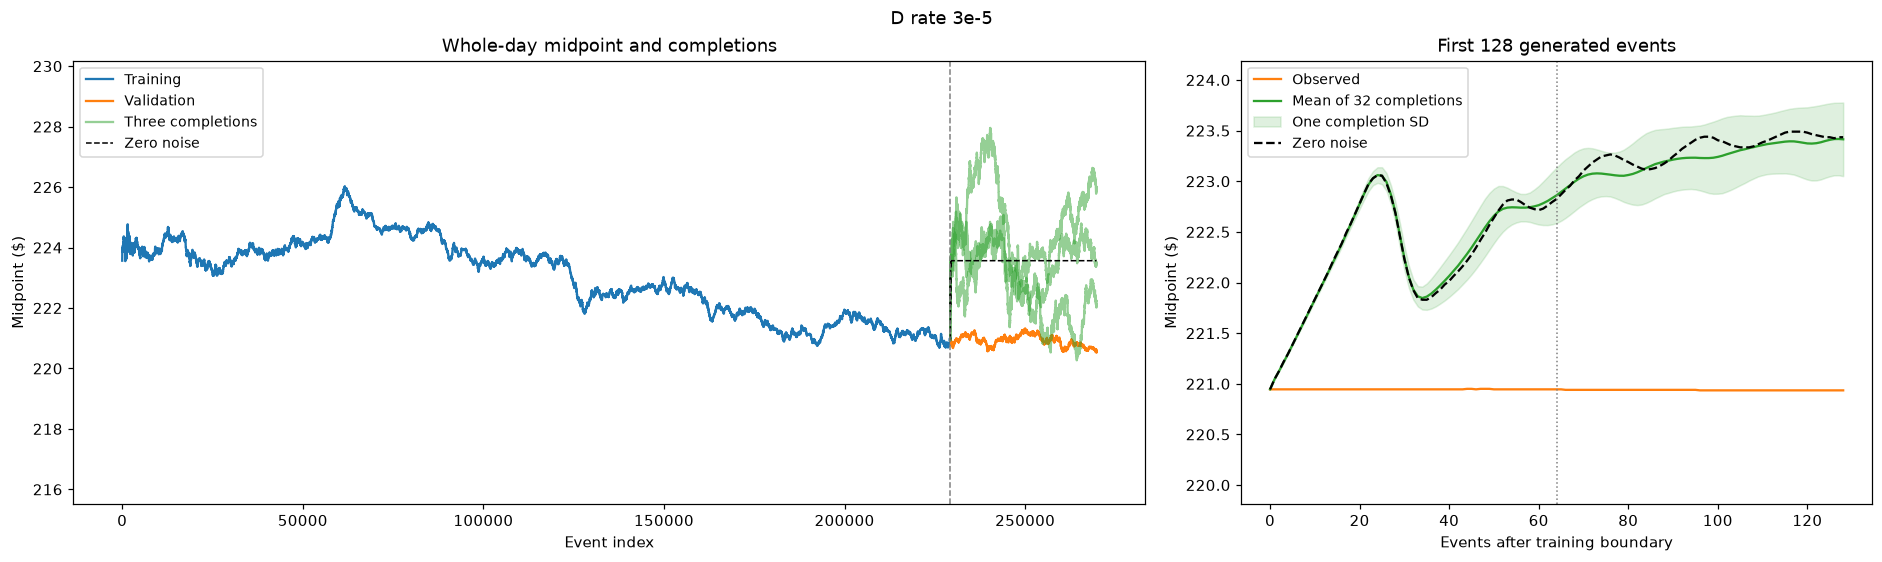

In [7]:
plot_experiment("discriminator_3e-5")


## Two generator updates per discriminator update


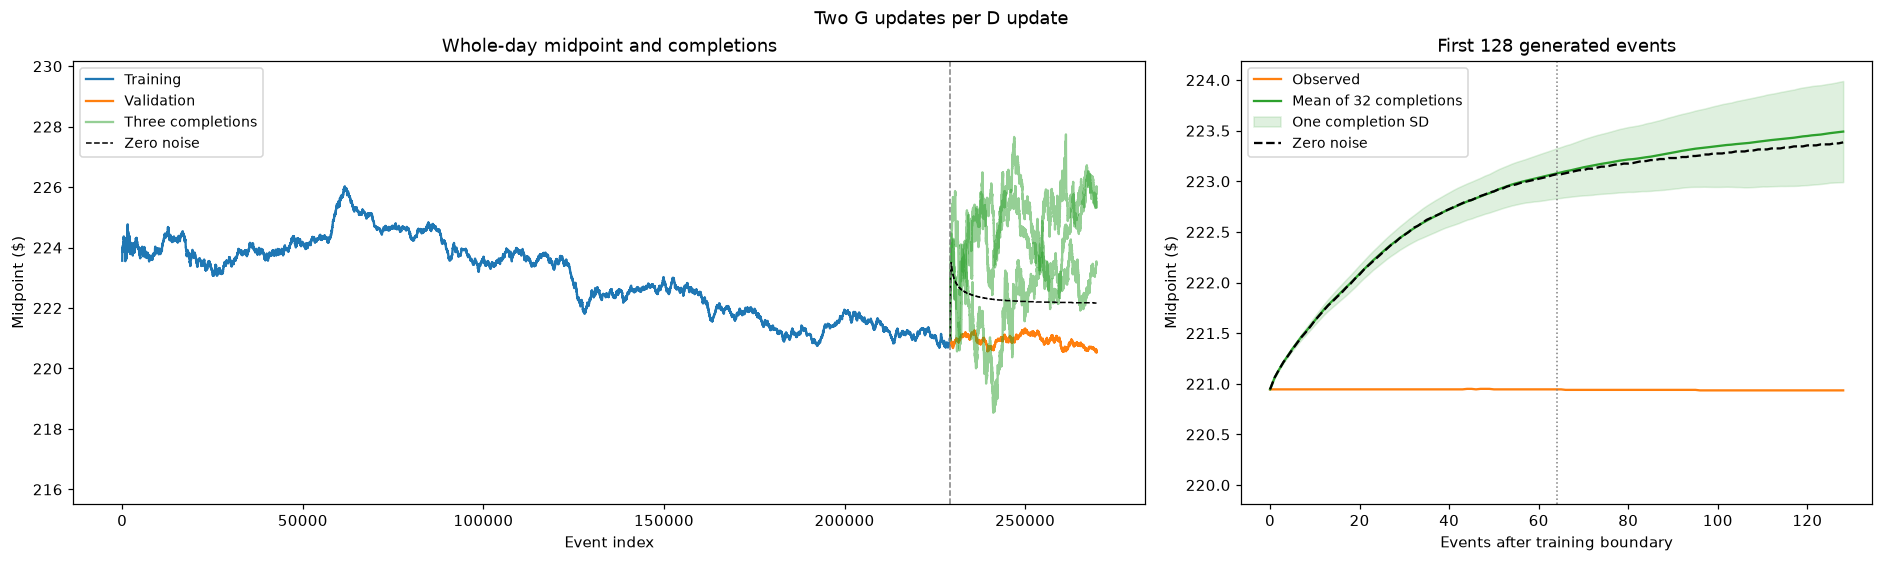

In [8]:
plot_experiment("generator_twice")


## Training duration and side effects

Snapshots show whether the jump improves or worsens as joint training continues.
The final table includes reconstruction and price-change variation. GAN losses
alone do not establish that the prices are realistic: weakening the discriminator
can lower the generator loss without improving generation.

This first sweep uses **one training seed**. The results establish what happened
in these controlled runs; any preferred setting should be repeated with other
training seeds before claiming a reliable improvement.


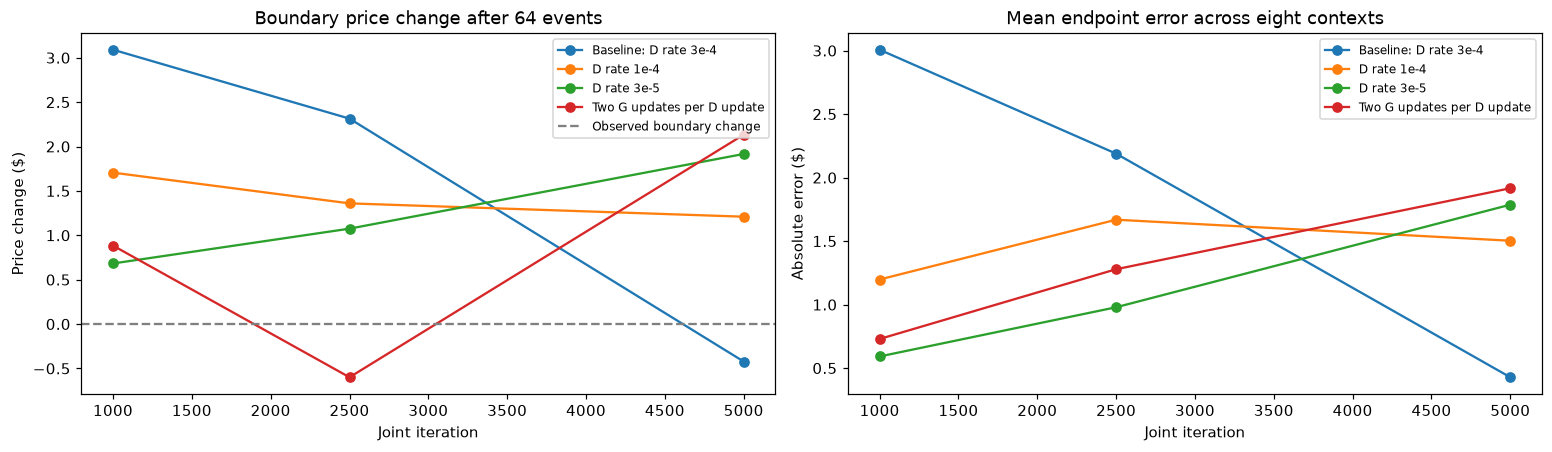

,context_reconstruction_mse,boundary_change_std_dollars,boundary_observed_change_std_dollars,last100_discriminator_loss,last100_generator_adversarial_loss
experiment,,,,,
Baseline: D rate 3e-4,0.004373,0.020051,0.00125,0.013029,7.728625
D rate 1e-4,0.000891,0.024771,0.00125,0.825217,2.178614
D rate 3e-5,0.000495,0.081145,0.00125,1.385543,0.669741
Two G updates per D update,0.000675,0.022382,0.00125,1.383216,0.703334


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")
for name in EXPERIMENTS:
    rows = snapshots.loc[snapshots["experiment"] == LABELS[name]]
    axes[0].plot(rows["joint_step"], rows["boundary_64_event_change_dollars"],
                 marker="o", label=LABELS[name])
    axes[1].plot(rows["joint_step"], rows["context_mean_abs_64_event_error_dollars"],
                 marker="o", label=LABELS[name])
axes[0].axhline(observed_change, color="gray", linestyle="--", label="Observed boundary change")
axes[0].set(title="Boundary price change after 64 events", xlabel="Joint iteration",
            ylabel="Price change ($)")
axes[1].set(title="Mean endpoint error across eight contexts", xlabel="Joint iteration",
            ylabel="Absolute error ($)")
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

display(summary[[
    "context_reconstruction_mse", "boundary_change_std_dollars",
    "boundary_observed_change_std_dollars", "last100_discriminator_loss",
    "last100_generator_adversarial_loss",
]].round(6))


## Ordinary generated-window quality

This secondary check compares generated 64-event windows with real training
windows. Mean, standard-deviation, and event-change errors are averaged across
the 40 standardized features. Lower errors indicate a closer match. This checks
whether reducing the boundary jump comes with poorer ordinary generation.
Training windows are the distribution the unconditional generator was trained
to match; the later validation period has a different price distribution.


In [10]:
import torch
from dataset import WindowDataset
from evaluation import compare_sequences
from predict import generate_features, load_checkpoint

torch.set_num_threads(1)
windows = WindowDataset(training.features, 64, stride=64)
indices = torch.linspace(0, len(windows) - 1, 256).round().long()
real_windows = torch.stack([windows[index.item()] for index in indices])
quality_rows = []
for name in EXPERIMENTS:
    model, _ = load_checkpoint(RESULTS_DIR / f"{name}_seed_0" / "model.pt")
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(0)
        generated = generate_features(model, len(real_windows), 64)
    comparison = compare_sequences(real_windows, generated)
    errors = comparison["absolute_errors"]
    quality_rows.append({
        "experiment": LABELS[name],
        "feature_mean_error": errors["mean"],
        "feature_std_error": errors["std"],
        "feature_change_std_error": errors["change_std"],
        "lag1_correlation_error": errors["lag1_correlation"],
        "midpoint_change_std_ratio": (comparison["generated"]["change_std"][0]
                                      / comparison["real"]["change_std"][0]),
    })
native_quality = pd.DataFrame(quality_rows).set_index("experiment")
native_quality.to_csv(RESULTS_DIR / "native_window_quality.csv")
display(native_quality.round(6))


,feature_mean_error,feature_std_error,feature_change_std_error,lag1_correlation_error,midpoint_change_std_ratio
experiment,,,,,
Baseline: D rate 3e-4,2.620791,0.242258,0.254348,0.102065,20.516156
D rate 1e-4,0.883565,0.288362,0.297250,0.111787,28.089606
D rate 3e-5,1.303866,0.352204,0.189330,0.079661,28.737710
Two G updates per D update,1.539708,0.144815,0.305706,0.107945,12.447930


## What the experiments show

At 5,000 joint iterations, the observed price ends unchanged over the first
64 validation events. The mean generated changes are:

- **Fresh baseline:** -$0.42. The upward jump becomes downward drift. Reconstruction
  and ordinary generated-feature means deteriorate substantially; this is not a clean fix.
- **Discriminator rate 1e-4:** +$1.21. The upward drift decreases across the three
  snapshots (+$1.71, +$1.36, +$1.21), but remains large. This has the smallest final
  upward drift and feature-mean error among the three tuning alternatives.
- **Discriminator rate 3e-5:** +$1.92, with a peak mean rise of $2.12 within the first
  64 events. Its early improvement (+$0.68 at iteration 1,000) deteriorates with
  more training despite apparently balanced adversarial losses.
- **Two generator updates:** +$2.13. The change swings from +$0.88 to -$0.60 and
  then +$2.13 as training proceeds; extra generator updates do not reliably prevent drift.

The tuned models still rise by +$1.07, +$1.88, and +$2.13 with **zero noise**.
Ordinary generated windows have log-midpoint change standard deviations about
12–29 times the real training-window value. No tested setting establishes
realistic conditional continuation or ordinary generation.

These one-seed results do not justify simply adding training iterations or
selecting a model by GAN loss alone. A direct loss on short decoded continuations
from real contexts is the next focused experiment for the hand-off problem.
